# Chapter 31 — Modular Arithmetic

> **Prerequisites:** ch022 (Natural Numbers), ch023 (Integers), ch029 (Factorization)  
> **You will learn:**
> - What modular arithmetic is and why it forms a closed number system
> - The division algorithm and remainder structure
> - Congruence classes and modular equivalence
> - Modular inverses and when they exist
> - Why modular arithmetic is foundational to cryptography and hashing
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Modular arithmetic is arithmetic on a finite cycle. Instead of numbers extending to infinity, they wrap around at a fixed modulus.

The core idea: when you divide integer `a` by positive integer `n`, you get a quotient `q` and a remainder `r`. The remainder is the only part modular arithmetic cares about.

**Division algorithm:** For any integers `a` and `n > 0`, there exist unique integers `q` and `r` such that:
```
a = q·n + r,   where 0 ≤ r < n
```
We write `a mod n = r`, or equivalently `a ≡ r (mod n)`.

**Common misconception:** `a mod n` is not the same as `a % n` for negative numbers in all languages. In Python, `%` returns a non-negative result (following mathematical convention). In C/C++, `%` can return negative values. This chapter uses mathematical convention.

**What problem does this solve?**  
- Clocks: 17:00 is 5 PM — hours wrap around 12 or 24.  
- Hash tables: map arbitrary keys into a fixed-size array.  
- Cryptography: RSA, Diffie-Hellman, and AES all operate modulo large primes.  
- Error detection: checksums (ISBN, credit cards) use modular arithmetic.

---

## 2. Intuition & Mental Models

**Geometric analogy — the clock:**  
Think of mod 12 as a clock face. Starting from 0, you count forward. When you reach 12, you return to 0. The position on the clock is the remainder. 14 o'clock wraps to 2. 25 o'clock wraps to 1.

**Computational analogy — the number line folded into a circle:**  
Think of mod n as folding the infinite integer number line into a circle with n positions (0 through n−1). Every integer lands on exactly one position. Two integers land on the same position if and only if they differ by a multiple of n.

**Congruence classes:**  
All integers that give the same remainder mod n form a *congruence class*. Under mod 3, the integers partition into three classes:
```
[0] = {..., -6, -3, 0, 3, 6, 9, ...}
[1] = {..., -5, -2, 1, 4, 7, 10, ...}
[2] = {..., -4, -1, 2, 5, 8, 11, ...}
```
Arithmetic on congruence classes is closed: the class of `(a + b)` depends only on the classes of `a` and `b`.

**Recall from ch023 (Integers):** The division algorithm was introduced there. Modular arithmetic is the full algebraic system built on that single operation.

---

## 3. Visualization

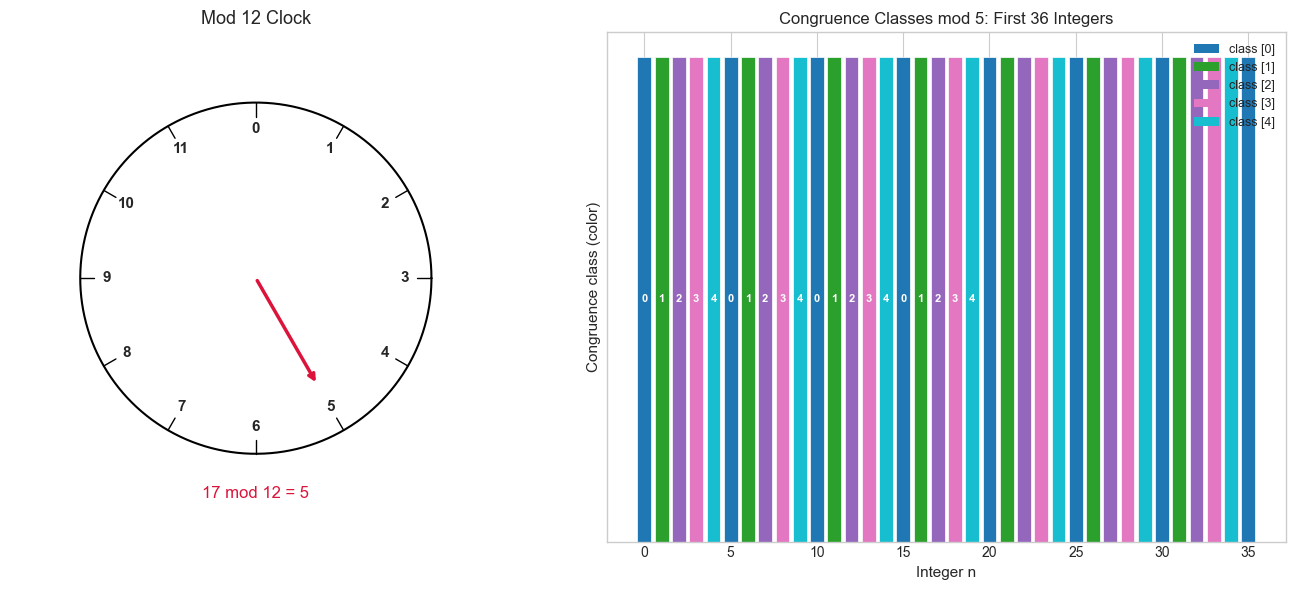

In [1]:
# --- Visualization: Modular arithmetic as a clock + congruence classes ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('seaborn-v0_8-whitegrid')

MODULUS = 12  # <-- try 7 or 5
N_INTEGERS = 36  # integers to display on the number line

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Clock face showing mod 12 ---
ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1.5)

for k in range(MODULUS):
    angle = np.pi / 2 - 2 * np.pi * k / MODULUS
    x, y = 0.85 * np.cos(angle), 0.85 * np.sin(angle)
    ax.text(x, y, str(k), ha='center', va='center', fontsize=11, fontweight='bold')
    # tick
    ax.plot([0.92 * np.cos(angle), 1.0 * np.cos(angle)],
            [0.92 * np.sin(angle), 1.0 * np.sin(angle)], 'k-', linewidth=1)

# Highlight where 17 lands on a mod-12 clock
highlight = 17 % MODULUS
h_angle = np.pi / 2 - 2 * np.pi * highlight / MODULUS
ax.annotate('', xy=(0.7 * np.cos(h_angle), 0.7 * np.sin(h_angle)),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2.5))
ax.text(0, -1.25, f'17 mod {MODULUS} = {17 % MODULUS}', ha='center', fontsize=12, color='crimson')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.5, 1.4)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Mod {MODULUS} Clock', fontsize=13)

# --- Right: Congruence classes as colored stripes ---
ax2 = axes[1]
MOD_COLOR = 5  # <-- change modulus for color stripes
colors = plt.cm.tab10(np.linspace(0, 0.9, MOD_COLOR))

integers = np.arange(N_INTEGERS)
remainders = integers % MOD_COLOR

for i, (val, rem) in enumerate(zip(integers, remainders)):
    ax2.bar(i, 1, color=colors[rem], edgecolor='white', linewidth=0.5)
    if i < 20:
        ax2.text(i, 0.5, str(rem), ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[r], label=f'class [{r}]') for r in range(MOD_COLOR)]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=9)
ax2.set_xlabel('Integer n', fontsize=11)
ax2.set_ylabel('Congruence class (color)', fontsize=11)
ax2.set_title(f'Congruence Classes mod {MOD_COLOR}: First {N_INTEGERS} Integers', fontsize=12)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Congruence notation:**  
We say `a ≡ b (mod n)` if and only if `n` divides `(a - b)`, i.e., `n | (a - b)`.

This is an *equivalence relation* — it satisfies reflexivity, symmetry, and transitivity.

**Modular arithmetic is closed under addition and multiplication:**
```
If a ≡ a' (mod n) and b ≡ b' (mod n), then:
   a + b ≡ a' + b' (mod n)
   a · b ≡ a' · b' (mod n)
```
This is what makes ℤ/nℤ (integers mod n) a well-defined algebraic structure.

**Modular inverse:**  
The modular inverse of `a` modulo `n` is an integer `x` such that:
```
a · x ≡ 1 (mod n)
```
This exists *if and only if* gcd(a, n) = 1 (a and n are coprime).  
It is computed via the Extended Euclidean Algorithm *(introduced in ch023 — Integers)*.

**Fermat's Little Theorem (special case):**  
If `n` is prime and `gcd(a, n) = 1`, then:
```
a^(n-1) ≡ 1 (mod n)
```
This means the modular inverse of `a` mod prime `p` is `a^(p-2) mod p`.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Core modular arithmetic operations ---
import numpy as np

def mod_add(a, b, n):
    """
    Modular addition: (a + b) mod n.

    Args:
        a, b: integers
        n: modulus (positive integer)

    Returns:
        (a + b) % n, in range [0, n-1]
    """
    return (a + b) % n


def mod_mul(a, b, n):
    """
    Modular multiplication: (a * b) mod n.
    Python handles large integers natively, so no overflow.
    """
    return (a * b) % n


def mod_pow(base, exp, n):
    """
    Modular exponentiation: base^exp mod n.
    Uses fast repeated squaring (O(log exp) multiplications).

    Args:
        base: integer base
        exp: non-negative integer exponent
        n: modulus

    Returns:
        base^exp mod n
    """
    result = 1
    base = base % n
    while exp > 0:
        if exp % 2 == 1:          # if current bit is 1
            result = (result * base) % n
        exp //= 2                  # shift right one bit
        base = (base * base) % n   # square the base
    return result


def extended_gcd(a, b):
    """
    Extended Euclidean Algorithm.
    Returns (gcd, x, y) such that a*x + b*y = gcd(a, b).
    """
    if b == 0:
        return a, 1, 0
    gcd, x1, y1 = extended_gcd(b, a % b)
    return gcd, y1, x1 - (a // b) * y1


def mod_inverse(a, n):
    """
    Modular inverse of a modulo n.
    Returns x such that a*x ≡ 1 (mod n).
    Raises ValueError if gcd(a, n) != 1 (inverse doesn't exist).

    Args:
        a: integer
        n: modulus

    Returns:
        modular inverse in range [0, n-1]
    """
    gcd, x, _ = extended_gcd(a % n, n)
    if gcd != 1:
        raise ValueError(f"Modular inverse of {a} mod {n} does not exist: gcd={gcd}")
    return x % n  # ensure positive result


# --- Validation ---
print("=== Basic operations ===")
print(f"(17 + 8) mod 12 = {mod_add(17, 8, 12)}   (expected: 1)")
print(f"(7 * 5) mod 11  = {mod_mul(7, 5, 11)}    (expected: 2)")

print("\n=== Modular exponentiation ===")
print(f"2^10 mod 1000   = {mod_pow(2, 10, 1000)}  (expected: 24)")
print(f"3^100 mod 97    = {mod_pow(3, 100, 97)}    (verify: pow(3,100,97)={pow(3,100,97)})")

print("\n=== Modular inverse ===")
a, n = 3, 11
inv = mod_inverse(a, n)
print(f"Inverse of {a} mod {n} = {inv}")
print(f"Verification: {a} * {inv} mod {n} = {mod_mul(a, inv, n)}   (should be 1)")

print("\n=== Fermat's Little Theorem check ===")
p = 13  # prime
a = 7
print(f"a^(p-1) mod p = {a}^{p-1} mod {p} = {mod_pow(a, p-1, p)}   (should be 1 by FLT)")

=== Basic operations ===
(17 + 8) mod 12 = 1   (expected: 1)
(7 * 5) mod 11  = 2    (expected: 2)

=== Modular exponentiation ===
2^10 mod 1000   = 24  (expected: 24)
3^100 mod 97    = 81    (verify: pow(3,100,97)=81)

=== Modular inverse ===
Inverse of 3 mod 11 = 4
Verification: 3 * 4 mod 11 = 1   (should be 1)

=== Fermat's Little Theorem check ===
a^(p-1) mod p = 7^12 mod 13 = 1   (should be 1 by FLT)


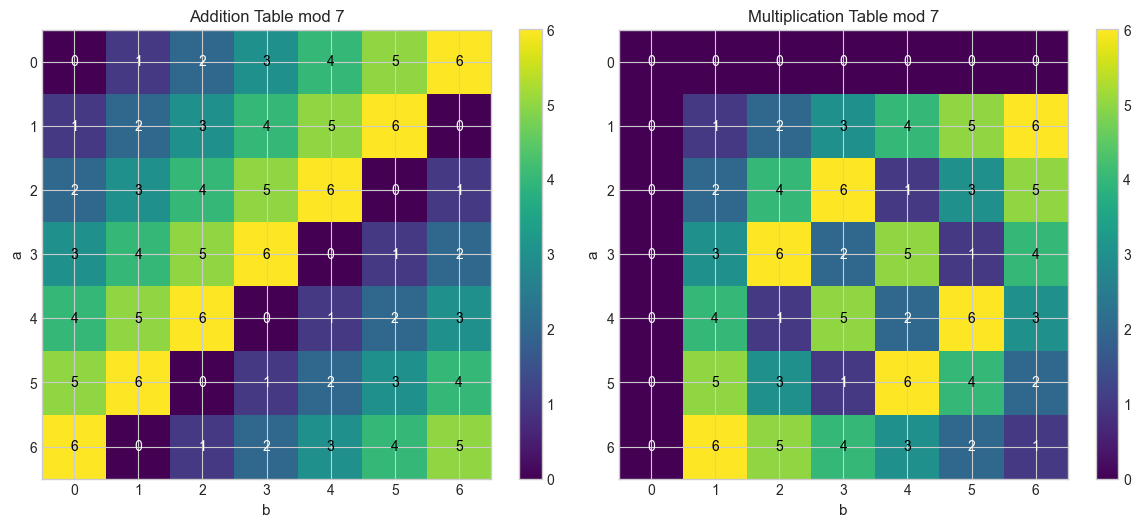

In [3]:
# --- Addition and multiplication tables mod n ---
import matplotlib.pyplot as plt
import numpy as np

MOD = 7  # <-- try 5, 6, 8

add_table = np.array([[(i + j) % MOD for j in range(MOD)] for i in range(MOD)])
mul_table = np.array([[(i * j) % MOD for j in range(MOD)] for i in range(MOD)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, table, title in zip(axes, [add_table, mul_table], ['Addition', 'Multiplication']):
    im = ax.imshow(table, cmap='viridis', aspect='equal')
    ax.set_xticks(range(MOD))
    ax.set_yticks(range(MOD))
    ax.set_xlabel('b', fontsize=11)
    ax.set_ylabel('a', fontsize=11)
    ax.set_title(f'{title} Table mod {MOD}', fontsize=12)
    for i in range(MOD):
        for j in range(MOD):
            ax.text(j, i, str(table[i, j]), ha='center', va='center',
                    fontsize=10, color='white' if table[i, j] < MOD // 2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Notice: when MOD is prime, every nonzero element appears in every row/column
# of the multiplication table (it forms a field). Try MOD=6 to see it break.

---

## 6. Experiments

In [4]:
# --- Experiment 1: When does a modular inverse exist? ---
# Hypothesis: a^(-1) mod n exists iff gcd(a, n) = 1.
#             When n is prime, every nonzero a has an inverse.
# Try changing: set n to a prime vs a composite number.

import math

n = 12  # <-- modify: try 7 (prime), 12 (composite), 15 (composite)

print(f"Modular inverses mod {n}:")
print(f"{'a':>4}  {'gcd(a,n)':>8}  {'inverse':>10}")
print("-" * 28)
for a in range(1, n):
    g = math.gcd(a, n)
    try:
        inv = mod_inverse(a, n)
        print(f"{a:>4}  {g:>8}  {inv:>10}")
    except ValueError:
        print(f"{a:>4}  {g:>8}  {'none':>10}  (gcd ≠ 1)")

Modular inverses mod 12:
   a  gcd(a,n)     inverse
----------------------------
   1         1           1
   2         2        none  (gcd ≠ 1)
   3         3        none  (gcd ≠ 1)
   4         4        none  (gcd ≠ 1)
   5         1           5
   6         6        none  (gcd ≠ 1)
   7         1           7
   8         4        none  (gcd ≠ 1)
   9         3        none  (gcd ≠ 1)
  10         2        none  (gcd ≠ 1)
  11         1          11


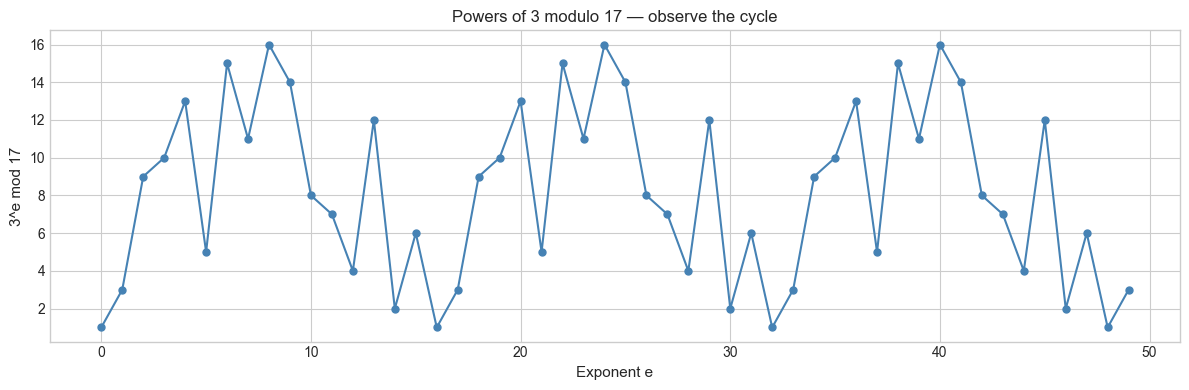

Multiplicative order of 3 mod 17 = 16


In [5]:
# --- Experiment 2: Modular exponentiation cycles ---
# Hypothesis: powers of a mod n form a repeating cycle.
#             The cycle length (order) divides φ(n) (Euler's totient).
# Try changing: vary BASE and MODULUS, observe the cycle length.

import matplotlib.pyplot as plt

BASE = 3    # <-- modify
MODULUS = 17  # <-- modify (try prime and composite)
MAX_EXP = 50

powers = [mod_pow(BASE, e, MODULUS) for e in range(MAX_EXP)]

plt.figure(figsize=(12, 4))
plt.plot(range(MAX_EXP), powers, 'o-', markersize=5, color='steelblue')
plt.xlabel('Exponent e', fontsize=11)
plt.ylabel(f'{BASE}^e mod {MODULUS}', fontsize=11)
plt.title(f'Powers of {BASE} modulo {MODULUS} — observe the cycle', fontsize=12)
plt.tight_layout()
plt.show()

# Find the cycle length (multiplicative order)
for period in range(1, MODULUS):
    if mod_pow(BASE, period, MODULUS) == 1:
        print(f"Multiplicative order of {BASE} mod {MODULUS} = {period}")
        break

In [6]:
# --- Experiment 3: Chinese Remainder Theorem (CRT) intuition ---
# Hypothesis: if m1 and m2 are coprime, the system:
#    x ≡ a1 (mod m1)
#    x ≡ a2 (mod m2)
# has a unique solution mod (m1 * m2).
# Try changing: a1, a2, m1, m2 (keep m1, m2 coprime)

import math

a1, m1 = 2, 3   # <-- modify
a2, m2 = 3, 5   # <-- modify (ensure gcd(m1, m2) = 1)

assert math.gcd(m1, m2) == 1, "m1 and m2 must be coprime!"

M = m1 * m2
# CRT construction
M1, M2 = M // m1, M // m2
x = (a1 * M1 * mod_inverse(M1, m1) + a2 * M2 * mod_inverse(M2, m2)) % M

print(f"System: x ≡ {a1} (mod {m1}),  x ≡ {a2} (mod {m2})")
print(f"Solution: x = {x} (mod {M})")
print(f"Verification: {x} mod {m1} = {x % m1} (want {a1}), {x} mod {m2} = {x % m2} (want {a2})")

System: x ≡ 2 (mod 3),  x ≡ 3 (mod 5)
Solution: x = 8 (mod 15)
Verification: 8 mod 3 = 2 (want 2), 8 mod 5 = 3 (want 3)


---

## 7. Exercises

**Easy 1.** Compute by hand (then verify in Python): `(2^15) mod 7`. Use repeated squaring, not brute force.  
*(Expected: a single integer in [0, 6])*

**Easy 2.** What is the modular inverse of 5 modulo 13? Verify your answer by multiplying.  
*(Expected: an integer x such that 5x ≡ 1 mod 13)*

**Medium 1.** Write a function `is_prime_fermat(n, k=10)` that tests primality using Fermat's Little Theorem: randomly choose `k` bases `a`, compute `a^(n-1) mod n`, and return `True` if all results are 1. Test it on primes and composites. *(Hint: this is probabilistic — what breaks it for n=561?)*

**Medium 2.** Build the full addition and multiplication tables for ℤ/6ℤ and ℤ/7ℤ. Identify which elements have multiplicative inverses in each. What structural difference do you observe between mod 6 and mod 7?

**Hard.** Implement a general solver for systems of two congruences using CRT. Then use it to answer: find the smallest positive integer that leaves remainder 3 when divided by 7, remainder 5 when divided by 11, and remainder 2 when divided by 13. *(Challenge: extend CRT to three moduli by applying it iteratively)*

---

## 8. Mini Project — ISBN Check Digit Validator

**Problem:** ISBN-10 and ISBN-13 codes embed a check digit computed via modular arithmetic. A single-digit transcription error always changes the checksum, catching the mistake.

**Task:** Implement both ISBN-10 and ISBN-13 validators from scratch, then generate all valid single-digit-error mutations of a given ISBN and verify every one fails validation.

In [ ]:
# --- Mini Project: ISBN Check Digit Validator ---
# Problem: Verify ISBN-10 and ISBN-13 checksums using modular arithmetic.
# Dataset: hardcoded valid ISBNs; generate error mutations programmatically.
# Task: implement validators, then show error detection rate.

def isbn10_valid(isbn_str):
    """
    Validate ISBN-10.
    Rule: sum(d_i * (10 - i) for i in 0..9) ≡ 0 (mod 11)
    Last digit can be 'X' representing 10.

    Args:
        isbn_str: string of 10 characters (digits or trailing 'X')

    Returns:
        True if valid
    """
    isbn = isbn_str.replace('-', '').replace(' ', '')
    if len(isbn) != 10:
        return False
    # TODO: complete this function
    total = 0
    for i, ch in enumerate(isbn):
        if ch == 'X' and i == 9:
            digit = 10
        elif ch.isdigit():
            digit = int(ch)
        else:
            return False
        total += digit * (10 - i)
    return total % 11 == 0


def isbn13_valid(isbn_str):
    """
    Validate ISBN-13.
    Rule: sum(d_i * (1 if i even else 3) for i in 0..12) ≡ 0 (mod 10)

    Args:
        isbn_str: string of 13 digits

    Returns:
        True if valid
    """
    isbn = isbn_str.replace('-', '').replace(' ', '')
    if len(isbn) != 13 or not isbn.isdigit():
        return False
    # TODO: implement the weighted sum and mod-10 check
    weights = [1 if i % 2 == 0 else 3 for i in range(13)]
    total = sum(int(d) * w for d, w in zip(isbn, weights))
    return total % 10 == 0


def generate_single_digit_errors(isbn_str):
    """
    Generate all ISBN strings that differ from isbn_str in exactly one digit.
    Returns list of (position, mutated_isbn) pairs.
    """
    isbn = isbn_str.replace('-', '')
    errors = []
    for i, ch in enumerate(isbn):
        if ch.isdigit():
            original = int(ch)
            for d in range(10):
                if d != original:
                    mutated = isbn[:i] + str(d) + isbn[i+1:]
                    errors.append((i, mutated))
    return errors


# Test with known valid ISBNs
valid_isbn10 = "0306406152"   # Valid ISBN-10
valid_isbn13 = "9780306406157"  # Valid ISBN-13

print(f"ISBN-10 '{valid_isbn10}' valid: {isbn10_valid(valid_isbn10)}")
print(f"ISBN-13 '{valid_isbn13}' valid: {isbn13_valid(valid_isbn13)}")

# Error detection analysis
errors = generate_single_digit_errors(valid_isbn13)
false_positives = [(pos, m) for pos, m in errors if isbn13_valid(m)]
print(f"\nISBN-13 error detection:")
print(f"  Total single-digit mutations: {len(errors)}")
print(f"  Detected as invalid: {len(errors) - len(false_positives)}")
print(f"  Missed (false positives): {len(false_positives)}")
print(f"  Detection rate: {(len(errors) - len(false_positives)) / len(errors) * 100:.1f}%")

---

## 9. Chapter Summary & Connections

**What we covered:**
- The division algorithm defines a unique remainder `r` for every pair `(a, n)`
- Congruence classes partition ℤ into `n` equivalence classes — arithmetic is closed on them
- Modular inverses exist iff gcd(a, n) = 1; computed via the Extended Euclidean Algorithm
- Fermat's Little Theorem: `a^(p-1) ≡ 1 (mod p)` for prime `p`, coprime `a`
- ℤ/pℤ is a *field* (all inverses exist) when `p` is prime — this is crucial for cryptography

**Backward connection:**  
This chapter makes full use of the Euclidean Algorithm *(introduced in ch023 — Integers)*. The GCD structure determines which modular operations are possible.

**Forward connections:**
- This reappears in **ch032 — Cycles and Remainders**, which explores the group-theoretic structure of ℤ/nℤ and multiplicative orders
- The Extended Euclidean Algorithm and modular inverse are the mathematical core of RSA encryption, previewed in **ch033 — Applications of Modulo in Programming**
- Modular arithmetic returns in **ch245 — Conditional Probability** as the structure underlying discrete probability spaces

**Going deeper:** Study *group theory* — ℤ/nℤ under addition is a cyclic group, and ℤ/pℤ under multiplication (excluding 0) is also cyclic. The structure of these groups explains the security of discrete-logarithm cryptography.